In [1]:
import os
import sys

project_root = os.path.abspath("..")
if project_root not in sys.path:
    sys.path.insert(0, project_root)

print("CWD:", os.getcwd())
print("Project root added:", project_root)

CWD: c:\Dev\Damage_Assessment_on_xBD\Model_Architectures Notebooks
Project root added: c:\Dev\Damage_Assessment_on_xBD


In [2]:
import torch
import torch.optim as optim

from src.dataloader import get_loaders
from src.eval import test_evaluation
from src.train import ComboLoss, run_training, plot_train_history
from src.model_unet import UNet

In [3]:
if torch.cuda.is_available():
    device = torch.device("cuda")
    print(f"Using GPU: {torch.cuda.get_device_name(0)}")
elif torch.backends.mps.is_available():
    device = torch.device("mps")
    print("Using MPS (Apple Silicon GPU)")
else:
    device = torch.device("cpu")
    print("Using CPU")

Using GPU: NVIDIA GeForce RTX 4070


In [4]:
# Config Hyperparameters (Adjust)
NUM_CLASSES = 5
BATCH_SIZE = 8
LR = 1e-4
NUM_EPOCHS = 50
PATIENCE = 8
BASE_FEATURES = 64
SAVE_PATH = "best_unet_combo.pth"

In [5]:
# Create Data Splits
from Preprocessing.xBD_splits import create_splits
img_dir = r"..\Preprocessing\tiles\images"
mask_dir = r"..\Preprocessing\tiles\masks"
train_files, val_files, test_files = create_splits(img_dir, mask_dir)
print(f"Train: {len(train_files)}  Val: {len(val_files)}  Test: {len(test_files)}")

Train: 12016
Val: 84
Test: 1592
Train: 12016  Val: 84  Test: 1592


In [6]:
train_loader, val_loader, test_loader = get_loaders(
    train_files, val_files, test_files, img_dir, mask_dir,
    batch_size=BATCH_SIZE, num_workers = 4, pin_memory = True, augment_train=False)

In [7]:
# Sanity check
images, masks = next(iter(train_loader))
print(f"Batch images: {images.shape}")  # [B, 6, H, W]
print(f"Batch masks:  {masks.shape}")   # [B, H, W]
print(f"Mask range:   {masks.min()} – {masks.max()}")
print(images.device)


Batch images: torch.Size([8, 6, 512, 512])
Batch masks:  torch.Size([8, 512, 512])
Mask range:   0 – 4
cpu


In [8]:
# Loss — ComboLoss (CE + Tversky)
class_counts = torch.tensor([
    3258249517, 287893139, 15076019, 19138232, 8918741
], dtype=torch.float32)

freqs = class_counts / class_counts.sum()
weights = 1.0 / torch.sqrt(freqs)
weights = weights / weights.mean()
class_weights = weights.to(device)

In [9]:
# Model
model = UNet(
    in_channels=6,
    num_classes=NUM_CLASSES,
    base_features=BASE_FEATURES).to(device)

total_params = sum(p.numel() for p in model.parameters())
print(f"Model parameters: {total_params:,}")
print(next(model.parameters()).device) 

Model parameters: 7,764,037
cuda:0


In [10]:
# Loss, Optimizer, LR Scheduler (Define Here)
criterion = ComboLoss(class_weights=class_weights, ce_weight=0.5,
                      tversky_weight=0.5, tversky_alpha=0.7,
                      tversky_beta=0.3, num_classes=NUM_CLASSES).to(device)

optimizer = optim.Adam(model.parameters(), lr=LR)

scheduler = optim.lr_scheduler.CosineAnnealingWarmRestarts(optimizer, T_0=5, T_mult=2, eta_min=1e-6)

In [11]:
history = run_training(
    model=model,
    train_loader=train_loader,
    val_loader=val_loader,
    criterion=criterion,
    optimizer=optimizer,
    scheduler=scheduler,
    device=device,
    num_epochs=NUM_EPOCHS,
    patience=PATIENCE,
    num_classes=NUM_CLASSES,
    save_path=SAVE_PATH, verbose = True)



Epoch 1/25  (lr=1.00e-04)
  Train Loss: 0.7794  |  Val Loss: 0.4778
  Train mIoU: 0.2836  |  Val mIoU: 0.2933
  Train Acc:  0.8723  |  Val Acc:  0.9773
  Val Per-Class:
    Class                IoU     Prec   Recall
    -----------------------------------------
    No Damage         0.9780   0.9867   0.9910
    Minor             0.4720   0.7353   0.5687
    Major             0.0000   0.0000   0.0000
    Destroyed         0.0008   0.0010   0.0048
    Unclassified      0.0156   0.0178   0.1153
  *** Saved new best model (mIoU=0.2933) ***



Epoch 2/25  (lr=9.05e-05)
  Train Loss: 0.5674  |  Val Loss: 0.4547
  Train mIoU: 0.3563  |  Val mIoU: 0.2839
  Train Acc:  0.9208  |  Val Acc:  0.9651
  Val Per-Class:
    Class                IoU     Prec   Recall
    -----------------------------------------
    No Damage         0.9684   0.9915   0.9765
    Minor             0.4375   0.5877   0.6314
    Major             0.0066   0.0071   0.0864
    Destroyed         0.0046   0.0047   0.1503
    Unclassified      0.0024   0.0026   0.0381



Epoch 3/25  (lr=6.58e-05)
  Train Loss: 0.5130  |  Val Loss: 0.4161
  Train mIoU: 0.3951  |  Val mIoU: 0.3114
  Train Acc:  0.9313  |  Val Acc:  0.9795
  Val Per-Class:
    Class                IoU     Prec   Recall
    -----------------------------------------
    No Damage         0.9809   0.9936   0.9871
    Minor             0.5620   0.6802   0.7639
    Major             0.0006   0.0088   0.0006
    Destroyed         0.0125   0.0128   0.3478
    Unclassified      0.0008   0.0025   0.0013
  *** Saved new best model (mIoU=0.3114) ***



Epoch 4/25  (lr=3.52e-05)
  Train Loss: 0.4835  |  Val Loss: 0.4020
  Train mIoU: 0.4247  |  Val mIoU: 0.3158
  Train Acc:  0.9374  |  Val Acc:  0.9811
  Val Per-Class:
    Class                IoU     Prec   Recall
    -----------------------------------------
    No Damage         0.9815   0.9938   0.9875
    Minor             0.5793   0.6725   0.8070
    Major             0.0000   0.0000   0.0000
    Destroyed         0.0070   0.0105   0.0206
    Unclassified      0.0114   0.0259   0.0201
  *** Saved new best model (mIoU=0.3158) ***



Epoch 5/25  (lr=1.05e-05)
  Train Loss: 0.4640  |  Val Loss: 0.4078
  Train mIoU: 0.4449  |  Val mIoU: 0.3135
  Train Acc:  0.9408  |  Val Acc:  0.9793
  Val Per-Class:
    Class                IoU     Prec   Recall
    -----------------------------------------
    No Damage         0.9815   0.9941   0.9872
    Minor             0.5543   0.6750   0.7560
    Major             0.0017   0.0024   0.0067
    Destroyed         0.0056   0.0058   0.1479
    Unclassified      0.0244   0.0635   0.0382


...


Epoch 17/25  (lr=9.94e-05)
  Train Loss: 0.4127  |  Val Loss: 0.4028
  Train mIoU: 0.4995  |  Val mIoU: 0.3121
  Train Acc:  0.9464  |  Val Acc:  0.9753
  Val Per-Class:
    Class                IoU     Prec   Recall
    -----------------------------------------
    No Damage         0.9770   0.9963   0.9806
    Minor             0.5541   0.6230   0.8336
    Major             0.0110   0.0124   0.0896
    Destroyed         0.0074   0.0076   0.2563
    Unclassified      0.0110   0.0339   0.0160



Epoch 18/25  (lr=9.76e-05)
  Train Loss: 0.4104  |  Val Loss: 0.3971
  Train mIoU: 0.5048  |  Val mIoU: 0.3160
  Train Acc:  0.9469  |  Val Acc:  0.9776
  Val Per-Class:
    Class                IoU     Prec   Recall
    -----------------------------------------
    No Damage         0.9786   0.9947   0.9838
    Minor             0.5404   0.6212   0.8061
    Major             0.0000   0.0000   0.0000
    Destroyed         0.0000   0.0000   0.0000
    Unclassified      0.0609   0.0928   0.1507



Epoch 19/25  (lr=9.46e-05)
  Train Loss: 0.4031  |  Val Loss: 0.3956
  Train mIoU: 0.5142  |  Val mIoU: 0.3251
  Train Acc:  0.9481  |  Val Acc:  0.9776
  Val Per-Class:
    Class                IoU     Prec   Recall
    -----------------------------------------
    No Damage         0.9784   0.9951   0.9832
    Minor             0.5473   0.6201   0.8233
    Major             0.0031   0.0037   0.0184
    Destroyed         0.0110   0.0139   0.0500
    Unclassified      0.0856   0.1320   0.1960



Epoch 20/25  (lr=9.05e-05)
  Train Loss: 0.3945  |  Val Loss: 0.4235
  Train mIoU: 0.5225  |  Val mIoU: 0.3024
  Train Acc:  0.9491  |  Val Acc:  0.9743
  Val Per-Class:
    Class                IoU     Prec   Recall
    -----------------------------------------
    No Damage         0.9816   0.9955   0.9860
    Minor             0.4749   0.6639   0.6252
    Major             0.0163   0.0164   0.7055
    Destroyed         0.0067   0.0071   0.1068
    Unclassified      0.0324   0.1026   0.0452



Epoch 21/25  (lr=8.55e-05)
  Train Loss: 0.3835  |  Val Loss: 0.4249
  Train mIoU: 0.5376  |  Val mIoU: 0.3043
  Train Acc:  0.9507  |  Val Acc:  0.9726
  Val Per-Class:
    Class                IoU     Prec   Recall
    -----------------------------------------
    No Damage         0.9798   0.9959   0.9837
    Minor             0.4729   0.6398   0.6445
    Major             0.0113   0.0116   0.2757
    Destroyed         0.0035   0.0035   0.2088
    Unclassified      0.0541   0.1417   0.0804

Early stopping triggered after 21 epochs.


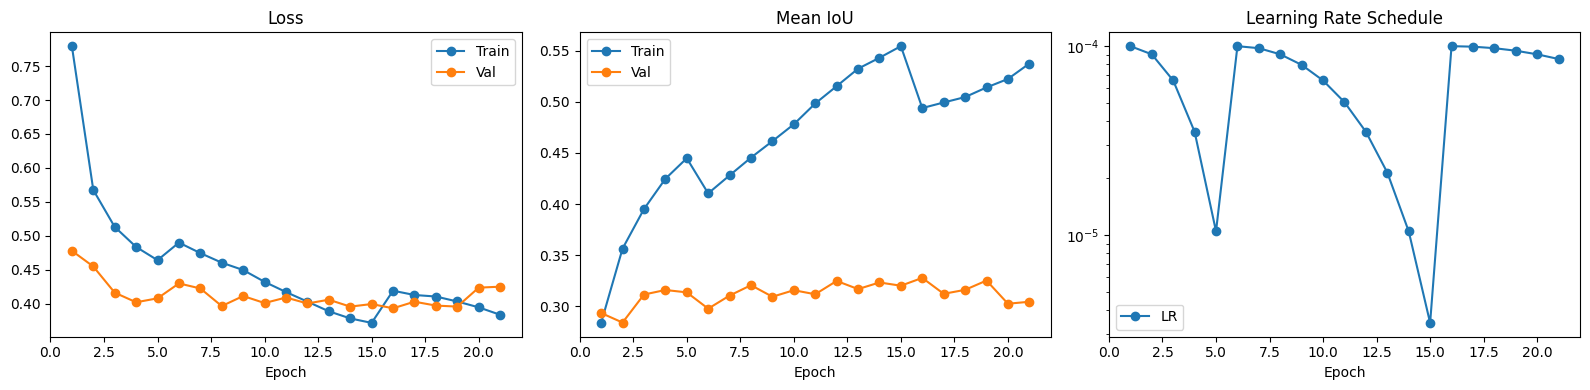

In [12]:
plot_train_history(history)

In [13]:
test_loss, test_metrics = test_evaluation(model, test_loader, criterion, device, SAVE_PATH, NUM_CLASSES)

Test Loss: 0.4049
Test mIoU: 0.3568
Test Acc:  0.9819

Class                IoU     Prec   Recall
No Damage         0.9857   0.9950   0.9907
Minor             0.5855   0.7071   0.7730
Major             0.0435   0.0594   0.1393
Destroyed         0.1383   0.2616   0.2270
Unclassified      0.0308   0.0338   0.2574
